# Algorithm evaluation data

This notebook generates synthetic data for evaluating background-extraction
algorithms, rather than the simpler case used in the tutorial demo.
It includes a moving point source, a varying background level, and counting
noise, together with three additional effects:

- A time-varying additive base pattern.
- A time-varying flat-field sensitivity pattern.
- A nonlinear detector response (linearity curve).

It writes `../data/tutorial_evaluation.fits`: the simulated data cube,
a source-exclusion mask, and the frame-dependent flat and base cubes.
The data test how well algorithms handle backgrounds whose spatial
patterns vary and whose recorded counts are not linearly additive.

In [1]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['image.origin'] = 'lower'

In [2]:
import astropy.io.fits as fits
import numpy as np
import scipy.ndimage as ndimage

## Observation model

Create 128 frames of 32 x 32 pixels. The array `const` is the reference
additive base image, and `flat` is the reference detector sensitivity map.
Although these reference images are fixed, their translated versions vary
from frame to frame. The scalar background level `flux` also varies
smoothly with frame number.

Four smooth latent sequences provide independent y/x translation offsets
for the base and flat patterns. They are generated from Gaussian random
sequences smoothed along the time axis. The reference patterns and latent
sequences use random seed 42.

The flat is a multiplicative sensitivity factor, not an additive background
component: it acts on both the varying background level and the source
before the detector response is applied.

In [3]:
rng = np.random.default_rng(42)
nz, ny, nx = 128, 32, 32

frac = np.linspace(0, 1, nz)
flat = ndimage.gaussian_filter(rng.normal(1.0, 1e-2, size=(ny, nx)), sigma=0.75)
const = ndimage.zoom(rng.normal(40000, 100, size=(8, 8)), 4)
flux = ndimage.gaussian_filter1d(
  rng.normal(50000.0, 10000.0, size=(nz, 1, 1)), sigma=8, axis=0
)
latent = ndimage.gaussian_filter1d(
  rng.normal([0.0] * 4, [1.0, 1.0, 0.5, 0.5], size=(nz, 4)),
  sigma=16,
  axis=0,
)

### Inspect the reference patterns

Display the reference additive base (`const`) and flat-field sensitivity
(`flat`). These are the patterns before the frame-dependent translations,
not the individual frames' base and flat images.

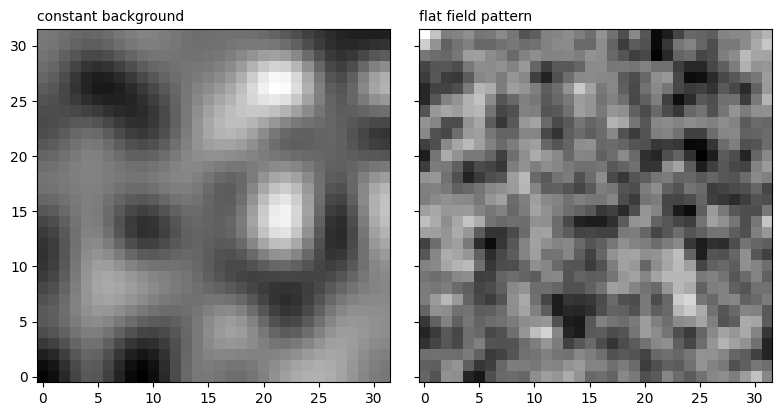

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

axes[0].imshow(const, cmap='gray')
axes[0].set_title('constant background', fontsize=10, loc='left')

axes[1].imshow(flat, cmap='gray')
axes[1].set_title('flat field pattern', fontsize=10, loc='left')

fig.tight_layout()
plt.show()

## Moving source template

Create a Gaussian point-source template with a width of 1.5 pixels in
sigma. Define its footprint using pixels above 20% of the peak.
The `offset` function translates either template across the detector;
the shifted footprint is rounded to form a binary source mask.

In [5]:
one = np.zeros((ny, nx))
one[15, 15] = 1.0
star = ndimage.gaussian_filter(one, sigma=1.5)
disk = np.asarray(star > 0.2 * star.max()).astype(np.float64)


def offset(star, x, y):
  dx = 16.0 - x
  dy = 16.0 - y
  return ndimage.affine_transform(star, np.eye(2), offset=(dy, dx))

### Inspect the source

Compare the point-source intensity profile with its binary footprint.

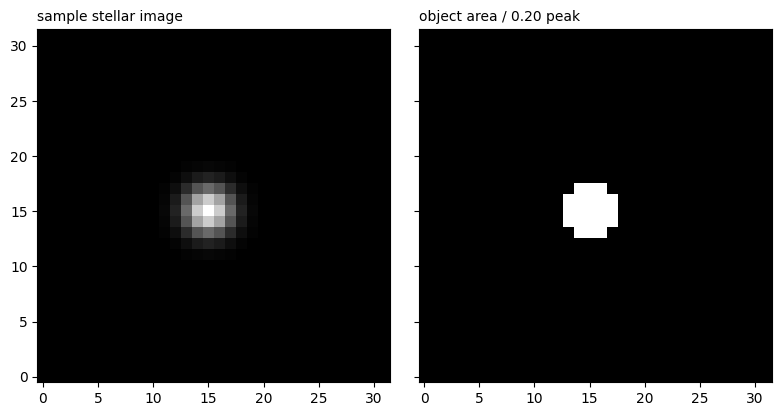

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

axes[0].imshow(star, cmap='gray')
axes[0].set_title('sample stellar image', fontsize=10, loc='left')

axes[1].imshow(disk, cmap='gray')
axes[1].set_title('object area / 0.20 peak', fontsize=10, loc='left')

fig.tight_layout()
plt.show()

## Generate the data cube and mask

For each frame, translate the base and flat reference images using their
respective latent offsets. Nearest-edge extension is used for these two
patterns. Move the source along a straight path and form the pre-response
intensity:

```text
I[n] = base[n] + flat[n] * (flux[n] + signal * source[n])
```

Apply the synthetic detector response to this combined intensity:

```text
linearity(I) = lscale * tanh(I / lscale)
```

The scale `lscale = 5e5` controls the nonlinear compression. Since this
curve acts after the base, background, and source have been combined,
their recorded contributions are not simply additive.

Finally draw Poisson counts with mean `pscale * linearity(I)` and divide
by `pscale`. With `pscale = 1000`, this retains the response as the
expected value while reducing the counting-noise amplitude. These draws
use random seed 1.

Build a matching mask with 1 in the shifted source footprint and 0
elsewhere. The mask marks source pixels to exclude from fitting; it does
not describe the base/flat variations or the detector response.

Collect the translated base images in `ccube` and sensitivity maps in
`fcube`, both with shape `(time, y, x)`. These are the frame-dependent
components used to form the pre-response intensity; neither cube has
the linearity curve or Poisson sampling applied to it.

In [7]:
rng = np.random.default_rng(1)
data = np.zeros((nz, ny, nx))
mask = np.zeros((nz, ny, nx))
signal = 1000.0
pscale = 1000.0
lscale = 5e5
x = 10.0 + 20.0 * np.linspace(0, 1, nz)
y = 20.0 - 15.0 * np.linspace(0, 1, nz)

linearity = lambda x: np.tanh(x / lscale) * lscale
poisson = lambda x: rng.poisson(pscale * linearity(x)) / pscale

ccube = []
fcube = []

for n in range(nz):
  _const = ndimage.affine_transform(
    const, np.eye(2), (latent[n, 0], latent[n, 1]), mode='nearest'
  )
  _flat = ndimage.affine_transform(
    flat, np.eye(2), (latent[n, 2], latent[n, 3]), mode='nearest'
  )
  data[n] = poisson(_const + _flat * (flux[n] + signal * offset(star, x[n], y[n])))
  mask[n] = np.round(offset(disk, x[n], y[n])).astype(bool)
  ccube.append(_const)
  fcube.append(_flat)

data = np.array(data)
mask = np.array(mask)
ccube = np.array(ccube)
fcube = np.array(fcube)

### Inspect the linearity curve

Plot `100 * linearity(n) / n` over a count range spanning the simulated
data minimum and maximum. This is the response-to-input ratio, not the
derivative of the response curve. The legend reports its peak-to-peak
variation in percentage points over that range.

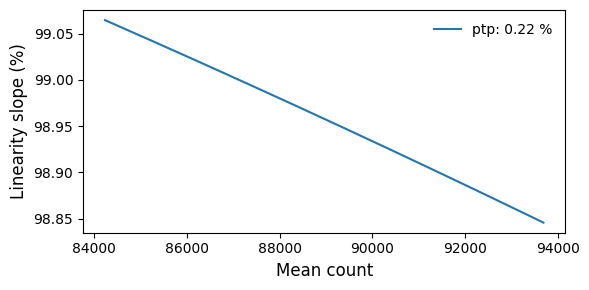

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))

n = np.linspace(data.min(), data.max(), 1000)

ax.plot(
  n, (linearity(n) / n) * 100, label=rf'ptp: {np.ptp(linearity(n) / n) * 100:.2f} %'
)

ax.set_xlabel('Mean count', fontsize=12)
ax.set_ylabel('Linearity slope (%)', fontsize=12)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

### Inspect the mean-subtracted data cube

Display six frames at intervals of twenty frames after subtracting the
temporal mean image from each. This highlights source motion and changing
background patterns; the stored data cube remains unsubtracted.

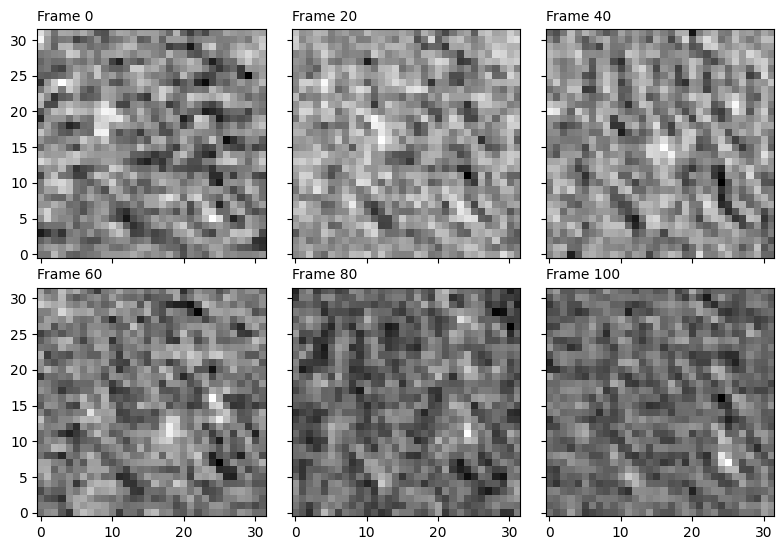

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(8, 5.5), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
  ax.imshow(data[n * 20] - data.mean(axis=0), cmap='gray')
  ax.set_title(f'Frame {n * 20}', fontsize=10, loc='left')

fig.tight_layout()
plt.show()

### Inspect the mask

Display the corresponding masks to check that the excluded region
follows the moving source.

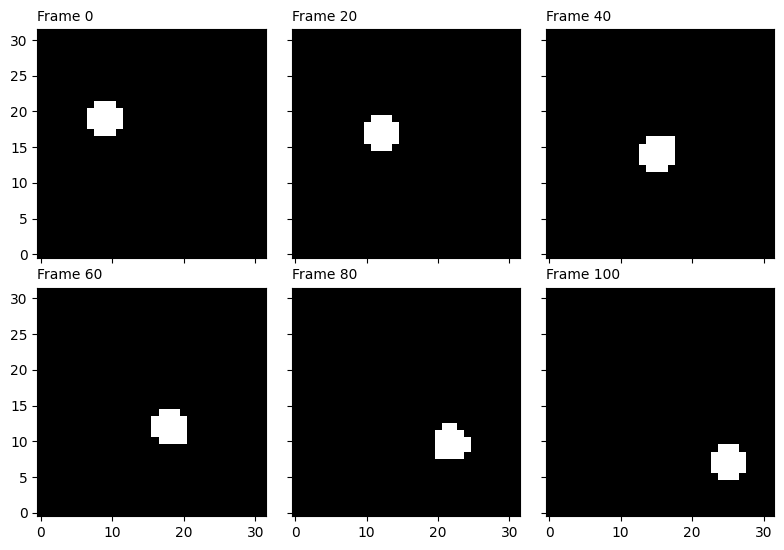

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(8, 5.5), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
  ax.imshow(mask[n * 20], cmap='gray')
  ax.set_title(f'Frame {n * 20}', fontsize=10, loc='left')

fig.tight_layout()
plt.show()

## Assemble the FITS HDUs

Store the simulated counts, after the nonlinear response and Poisson
sampling, in the primary HDU. Add the following image extensions:

- `MASK`: the frame-wise source mask, with 1 excluded and 0 observed.
- `FLAT`: `fcube`, the translated sensitivity map for each frame.
- `CONST`: `ccube`, the translated additive base image for each frame.

All four HDUs contain 3D cubes with shape `(128, 32, 32)`, ordered as
`(time, y, x)`. Despite its name, `CONST` varies from frame to frame.
`FLAT` and `CONST` store the components before the nonlinear response
and counting noise, not separate contributions to the recorded counts.
The original 2D reference images, latent offsets, background-level
sequence, and combined noiseless background are not stored.

The header records `SEED=42` for the reference-pattern and latent-sequence
generation; the Poisson sampling uses seed 1. Display the HDU summary
before writing `../data/tutorial_evaluation.fits`.

In [11]:
header = fits.Header()

header['SEED'] = 42

phdu = fits.PrimaryHDU(data=data, header=header)
mhdu = fits.ImageHDU(data=mask, name='MASK')
fhdu = fits.ImageHDU(data=fcube, name='FLAT')
chdu = fits.ImageHDU(data=ccube, name='CONST')

hdul = fits.HDUList([phdu, mhdu, fhdu, chdu])
hdul.info()

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   (32, 32, 128)   float64   
  1  MASK          1 ImageHDU         9   (32, 32, 128)   float64   
  2  FLAT          1 ImageHDU         9   (32, 32, 128)   float64   
  3  CONST         1 ImageHDU         9   (32, 32, 128)   float64   


In [12]:
hdul.writeto('../data/tutorial_evaluation.fits', overwrite=True)